In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, isnan, when, desc, avg, expr

# Inisialisasi Spark Session
spark = SparkSession.builder \
    .appName("EDA-IPUMS-SDG10") \
    .getOrCreate()

# Path mengarah ke folder data yang di-mount Docker
file_path = "../data/raw/ipums_brazil_mexico_2010.csv"

# Membaca data CSV
df = spark.read.csv(file_path, header=True, inferSchema=True)

# Menampilkan skema dan 5 baris pertama
df.printSchema()
df.show(5)

print(f"Total Baris: {df.count():,}")
print(f"Total Kolom: {len(df.columns)}")

root
 |-- COUNTRY: integer (nullable = true)
 |-- YEAR: integer (nullable = true)
 |-- SAMPLE: integer (nullable = true)
 |-- SERIAL: long (nullable = true)
 |-- HHWT: double (nullable = true)
 |-- PERNUM: integer (nullable = true)
 |-- PERWT: double (nullable = true)
 |-- AGE: integer (nullable = true)
 |-- SEX: integer (nullable = true)
 |-- EDATTAIN: integer (nullable = true)
 |-- EDATTAIND: integer (nullable = true)
 |-- EMPSTAT: integer (nullable = true)
 |-- EMPSTATD: integer (nullable = true)
 |-- OCCISCO: integer (nullable = true)
 |-- INDGEN: integer (nullable = true)
 |-- INCTOT: integer (nullable = true)
 |-- INCEARN: integer (nullable = true)

+-------+----+--------+------+----+------+-----+---+---+--------+---------+-------+--------+-------+------+------+--------+
|COUNTRY|YEAR|  SAMPLE|SERIAL|HHWT|PERNUM|PERWT|AGE|SEX|EDATTAIN|EDATTAIND|EMPSTAT|EMPSTATD|OCCISCO|INDGEN|INCTOT| INCEARN|
+-------+----+--------+------+----+------+-----+---+---+--------+---------+-------+-----

In [4]:
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, isnan, when, expr, avg

# Fungsi pembantu untuk mencatat waktu antar-sel
def print_time(start, step_name):
    elapsed = time.time() - start
    print(f"⏱️ [WAKTU] {step_name} selesai dalam: {elapsed:.2f} detik")
    return time.time()

In [5]:
t_start = time.time()

print("Memulai Spark Session...")
spark = SparkSession.builder \
    .appName("EDA-IPUMS-SDG10-Benchmarked") \
    .getOrCreate()

t_step = print_time(t_start, "Inisialisasi Spark")


Memulai Spark Session...
⏱️ [WAKTU] Inisialisasi Spark selesai dalam: 0.03 detik


In [6]:
t_step = time.time()
file_path = "../data/raw/ipums_brazil_mexico_2010.csv"
print(f"Membaca data dari {file_path}...")

# Membaca data CSV (ingat: '../data' karena notebook mount volume dari root)
df = spark.read.csv(file_path, header=True, inferSchema=True)

# Memanggil .count() agar Spark mengeksekusi I/O ke dalam memori
total_rows = df.count() 

print(f"Total Baris: {total_rows:,}")
print(f"Total Kolom: {len(df.columns)}")
t_step = print_time(t_step, "Membaca Data CSV (I/O)")

Membaca data dari ../data/raw/ipums_brazil_mexico_2010.csv...
Total Baris: 32,573,874
Total Kolom: 17
⏱️ [WAKTU] Membaca Data CSV (I/O) selesai dalam: 25.33 detik


In [7]:
t_step = time.time()
print("Mengecek Missing Values...")

cols_to_check = ["COUNTRY", "YEAR", "AGE", "SEX", "EMPSTAT", "INCTOT"]
null_counts = df.select([
    count(when(isnan(c) | col(c).isNull(), c)).alias(c)
    for c in cols_to_check
]).toPandas()

display(null_counts.T)
t_step = print_time(t_step, "Pengecekan Missing Values")

Mengecek Missing Values...


,0
COUNTRY,0
YEAR,0
AGE,0
SEX,0
EMPSTAT,0
INCTOT,11938402


⏱️ [WAKTU] Pengecekan Missing Values selesai dalam: 12.79 detik


In [8]:
t_step = time.time()
print("Melakukan Filtering Usia & Pendapatan...")

# Filter usia produktif dan pendapatan valid
df_clean = df.filter(
    (col("AGE") >= 18) & 
    (col("AGE") <= 65) & 
    (col("INCTOT") >= 0) & 
    (col("INCTOT") < 9999998)
)

clean_rows = df_clean.count()
print(f"Total Baris setelah dibersihkan: {clean_rows:,}")
t_step = print_time(t_step, "Filtering Data")

Melakukan Filtering Usia & Pendapatan...
Total Baris setelah dibersihkan: 12,879,303
⏱️ [WAKTU] Filtering Data selesai dalam: 12.19 detik


In [9]:
t_step = time.time()
print("Menghitung Statistik Agregasi...")

summary_income = df_clean.groupBy("COUNTRY").agg(
    avg("INCTOT").alias("Rata_rata_Pendapatan"),
    expr("percentile_approx(INCTOT, 0.5)").alias("Median_Pendapatan"),
    expr("max(INCTOT)").alias("Max_Pendapatan"),
    count("INCTOT").alias("Jumlah_Populasi")
).toPandas()

display(summary_income)
t_step = print_time(t_step, "Agregasi Statistik Pendapatan")

Menghitung Statistik Agregasi...


,COUNTRY,Rata_rata_Pendapatan,Median_Pendapatan,Max_Pendapatan,Jumlah_Populasi
0,76,882.803298,510,1906523,12879303


⏱️ [WAKTU] Agregasi Statistik Pendapatan selesai dalam: 18.70 detik


In [10]:
t_step = time.time()
print("Mengambil sampel (5%) untuk visualisasi...")

df_sample = df_clean.select("COUNTRY", "SEX", "INCTOT").sample(fraction=0.05, seed=42).toPandas()
t_step = print_time(t_step, "Sampling Data (Spark ke Pandas)")

Mengambil sampel (5%) untuk visualisasi...
⏱️ [WAKTU] Sampling Data (Spark ke Pandas) selesai dalam: 13.33 detik


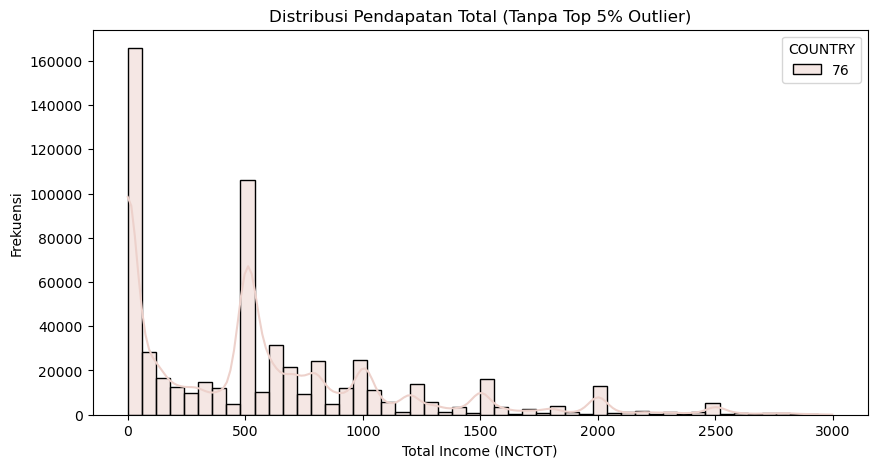

⏱️ [WAKTU] Render Visualisasi selesai dalam: 1.52 detik


1780239160.5858366

In [11]:
t_step = time.time()
# Menghapus top 5% outlier agar grafik tidak menyempit
q95 = df_sample['INCTOT'].quantile(0.95)
data_filtered = df_sample[df_sample['INCTOT'] < q95]

plt.figure(figsize=(10, 5))
sns.histplot(data=data_filtered, x="INCTOT", hue="COUNTRY", bins=50, kde=True)
plt.title("Distribusi Pendapatan Total (Tanpa Top 5% Outlier)")
plt.xlabel("Total Income (INCTOT)")
plt.ylabel("Frekuensi")
plt.show()

print_time(t_step, "Render Visualisasi")

In [12]:
t_step = time.time()
print("Mengevaluasi Pendapatan Nol (Zero Incomes)...")

# Menghitung jumlah orang dengan pendapatan 0 per negara
zero_income_stats = df_clean.withColumn(
    "is_zero", when(col("INCTOT") == 0, 1).otherwise(0)
).groupBy("COUNTRY").agg(
    count("INCTOT").alias("total_populasi"),
    expr("sum(is_zero)").alias("jumlah_nol"),
    expr("sum(is_zero) / count(INCTOT) * 100").alias("persentase_nol_persen")
).toPandas()

display(zero_income_stats)
t_step = print_time(t_step, "Evaluasi Zero Income")

Mengevaluasi Pendapatan Nol (Zero Incomes)...


,COUNTRY,total_populasi,jumlah_nol,persentase_nol_persen
0,76,12879303,3183056,24.714505


⏱️ [WAKTU] Evaluasi Zero Income selesai dalam: 14.08 detik


Agregasi Pendapatan berdasarkan Pendidikan (EDATTAIN)...


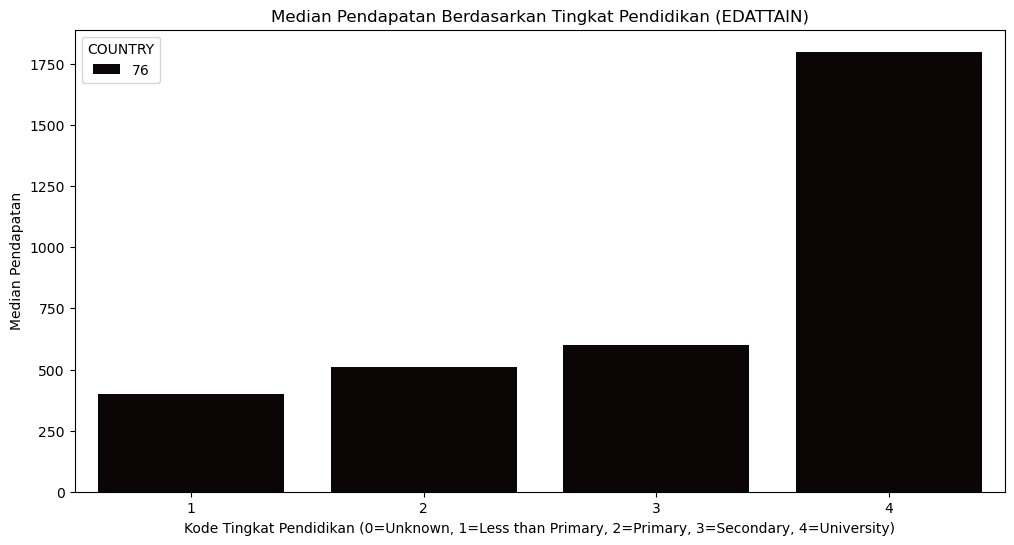

⏱️ [WAKTU] Evaluasi Pendidikan vs Pendapatan selesai dalam: 18.10 detik


In [14]:
t_step = time.time()
print("Agregasi Pendapatan berdasarkan Pendidikan (EDATTAIN)...")

# Menggunakan EDATTAIN sebagai ganti EDUC
educ_income = df_clean.groupBy("COUNTRY", "EDATTAIN").agg(
    expr("percentile_approx(INCTOT, 0.5)").alias("Median_Pendapatan"),
    count("INCTOT").alias("Jumlah_Orang")
).orderBy("COUNTRY", "EDATTAIN").toPandas()

# Plotting bar chart korelasi Pendidikan
plt.figure(figsize=(12, 6))
sns.barplot(data=educ_income, x="EDATTAIN", y="Median_Pendapatan", hue="COUNTRY", palette="mako")
plt.title("Median Pendapatan Berdasarkan Tingkat Pendidikan (EDATTAIN)")
plt.xlabel("Kode Tingkat Pendidikan (0=Unknown, 1=Less than Primary, 2=Primary, 3=Secondary, 4=University)")
plt.ylabel("Median Pendapatan")
plt.show()

t_step = print_time(t_step, "Evaluasi Pendidikan vs Pendapatan")

In [15]:
t_step = time.time()
print("Menghitung Porsi Kekayaan: Top 10% vs Bottom 40%...")

# Karena Spark sulit melakukan global rank dengan cepat, kita hitung threshold persentil
percentiles = df_clean.groupBy("COUNTRY").agg(
    expr("percentile_approx(INCTOT, 0.4)").alias("Batas_Bottom40"),
    expr("percentile_approx(INCTOT, 0.9)").alias("Batas_Top10"),
    expr("sum(INCTOT)").alias("Total_Kekayaan_Negara")
).toPandas()

display(percentiles)
print("💡 Insight: Nilai di atas adalah batas pendapatan untuk masuk ke golongan 40% terbawah atau 10% teratas. Jika angka 40% terbawah sangat kecil/nol, itu indikasi ketimpangan yang ekstrem.")
t_step = print_time(t_step, "Evaluasi Threshold Palma Ratio")

Menghitung Porsi Kekayaan: Top 10% vs Bottom 40%...


,COUNTRY,Batas_Bottom40,Batas_Top10,Total_Kekayaan_Negara
0,76,400,1800,11369891167


💡 Insight: Nilai di atas adalah batas pendapatan untuk masuk ke golongan 40% terbawah atau 10% teratas. Jika angka 40% terbawah sangat kecil/nol, itu indikasi ketimpangan yang ekstrem.
⏱️ [WAKTU] Evaluasi Threshold Palma Ratio selesai dalam: 17.58 detik


In [16]:
%run ../scripts/generate_sample.py

2026-05-31 15:20:51,443 [INFO] Membaca data penuh dari /home/jovyan/data/raw/ipums_brazil_mexico_2010.csv...
2026-05-31 15:21:12,449 [INFO] Mengambil sampel 10% (0.1) dari masing-masing negara...
2026-05-31 15:21:12,508 [INFO] Mengkonversi sampel ke Pandas DataFrame untuk disimpan sebagai 1 file CSV...
2026-05-31 15:21:56,160 [INFO] Total baris sampel berhasil ditarik: 3,257,454
2026-05-31 15:21:56,161 [INFO] Menyimpan sampel CSV ke /home/jovyan/data/raw/ipums_sample_10pct.csv...
2026-05-31 15:22:12,097 [INFO] ✅ Proses sampling selesai dalam 80.68 detik!
